In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nlu-data/RACE-H_v1_trn.jsonl
/kaggle/input/nlu-data/SATACT_v3_trn.jsonl
/kaggle/input/nlu-data/RACE-H_v1_tst.jsonl
/kaggle/input/nlu-data/SATACT_v3_tst.jsonl


In [ ]:
import torch
import json
import csv
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import os

#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
GLOBAL_Y_TRUE = []
GLOBAL_Y_PRED = []
GLOBAL_LOGITS = []

In [ ]:
# Advanced Tools
!pip install bert-score shap --quiet
from bert_score import score as bert_score

%matplotlib inline

In [ ]:
!mkdir -p results

In [ ]:
# CONFIG
path_to_nlu_dir = "/kaggle/input/"
data_dir = path_to_nlu_dir + "nlu-data/"
path_to_res = "/kaggle/working/"
save_dir = path_to_res + "results"
os.makedirs(save_dir, exist_ok=True)
datasets = [
    {"path": "RACE-H_v1_tst.jsonl", "name": "RACE-H"},
    {"path": "SATACT_v3_tst.jsonl", "name": "SATACT"}
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2-xl")
model = GPT2LMHeadModel.from_pretrained("gpt2-xl").to(device)
tokenizer.pad_token = tokenizer.eos_token
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1600)
    (wpe): Embedding(1024, 1600)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-47): 48 x GPT2Block(
        (ln_1): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D(nf=4800, nx=1600)
          (c_proj): Conv1D(nf=1600, nx=1600)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=6400, nx=1600)
          (c_proj): Conv1D(nf=1600, nx=6400)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1600, out_features=50257, bias=False)
)

In [ ]:
def get_prompt(example):
    if 'prompt' in example and example['prompt']:
        return example['prompt']
    elif 'context' in example and 'question' in example:
        return example['context'] + " " + example['question']
    elif 'question' in example:
        return example['question']
    else:
        return ""

def get_options(example):
    if "options" in example and example["options"]:
        return example["options"]
    elif all(k in example for k in ["answerA", "answerB", "answerC", "answerD"]):
        return [example["answerA"], example["answerB"], example["answerC"], example["answerD"]]
    else:
        return []

In [ ]:
# UTILS

def load_data(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    return [json.loads(l) for l in lines]

def prepare_input(prompt):
    enc = tokenizer(prompt, return_tensors="pt", truncation=True, padding=False).to(device)
    print(f"Input length before truncation: {enc['input_ids'].shape[-1]}")
    if enc['input_ids'].shape[-1] > 1024:
        enc['input_ids'] = enc['input_ids'][:, -1024:]
        enc['attention_mask'] = enc['attention_mask'][:, -1024:]
        print(f"Truncated to: {enc['input_ids'].shape[-1]}")
    return enc

In [ ]:
# PREDICTION

def predict(model, batch):
    preds = []
    logits_all_examples = []
    option_labels = ["A", "B", "C", "D"]
    for example in tqdm(batch):
        # Use helper functions to get the prompt and answer options.
        prompt = get_prompt(example)
        options = get_options(example)
        if not options:
            print("[WARN] No options provided in example.")
            continue
        print(f"Prompt: {prompt}, Options: {options}")  # Debug print
        log_probs = []
        for opt in options:
            full_input = prompt + " " + opt
            tokens = prepare_input(full_input)
            input_ids = tokens["input_ids"]
            attention_mask = tokens["attention_mask"]
            with torch.no_grad():
                output = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            logits = output.logits

            opt_tokens = tokenizer(opt, return_tensors="pt")["input_ids"][0].to(device)
            opt_len = opt_tokens.size(0)
            seq_logits = logits[0, -opt_len-1:-1, :]
            log_prob = 0
            for i, token_id in enumerate(opt_tokens):
                log_prob += torch.log_softmax(seq_logits[i], dim=-1)[token_id].item()
            log_probs.append(log_prob)
        pred_idx = np.argmax(log_probs)
        pred_label = option_labels[pred_idx]
        preds.append(pred_idx)
        logits_all_examples.append(log_probs)
        print(f"Prediction: {pred_label}, Log probs: {log_probs}")
    return preds, logits_all_examples

In [ ]:
# EVALUATION

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate(y_true, y_pred, label_names):
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=label_names)
    cm = confusion_matrix(y_true, y_pred)
    return acc, report, cm

In [ ]:
# ATTENTION HEATMAP

def get_attention_map(model, input_text):
    inputs = prepare_input(input_text)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    attn = outputs.attentions[-1][0]
    mean_attn = attn.mean(dim=0).cpu().numpy()
    return mean_attn, tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

def plot_attention_heatmap(attn_map, tokens, max_tokens=10):
    attn_map = attn_map[:max_tokens, :max_tokens]
    tokens = tokens[:max_tokens]
    plt.figure(figsize=(8, 6))
    sns.heatmap(attn_map, xticklabels=tokens, yticklabels=tokens, cmap="coolwarm")
    plt.title("GPT-2 XL Final Layer Attention")
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
# LOGIT LENS

def logit_lens_visual(model, input_text):
    tokens = prepare_input(input_text)
    with torch.no_grad():
        outputs = model(**tokens, output_hidden_states=True)
    logits = outputs.logits[0]
    confidences = logits.softmax(dim=-1).max(dim=-1).values.cpu().numpy()
    return confidences

In [ ]:
# HEURISTIC PROBES

def shallow_heuristic_check(question, options):
    lower_q = question.lower()
    matches = [int(opt.lower() in lower_q or any(word in lower_q for word in opt.lower().split()))
               for opt in options]
    print(f"Shallow heuristic - Question: {question}, Matches: {matches}")
    return matches

In [ ]:
# TRUE ATTENTION ROLLOUT

def true_attention_rollout(model, input_text):
    inputs = prepare_input(input_text)
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    attentions = outputs.attentions
    rollout = torch.stack(attentions).squeeze(1)
    rollout = rollout.mean(dim=1)
    rollout = rollout.mean(dim=0)
    rollout_np = rollout.cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    return rollout_np, tokens

def plot_attention_rollout(attn_rollout, tokens, max_tokens=10):
    attn_rollout = attn_rollout[:max_tokens, :max_tokens]
    tokens = tokens[:max_tokens]
    plt.figure(figsize=(8, 6))
    sns.heatmap(attn_rollout, xticklabels=tokens, yticklabels=tokens, cmap="coolwarm")
    plt.title("True Attention Rollout Across All Layers (Mean Heads)")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# TOKEN-LEVEL CONTRASTIVE ABLATION

import random

def token_contrastive_ablation(model, input_text, options, max_ablation_tokens=20):
    tokens = tokenizer(input_text, return_tensors="pt").to(device)
    input_ids = tokens['input_ids']
    token_len = input_ids.size(1)
    token_indices = random.sample(range(token_len), min(token_len, max_ablation_tokens))

    baseline_pred, _ = predict(model, [{"prompt": input_text, "options": options}])[0]
    scores = []

    for i in token_indices:
        ablated_input = input_ids.clone()
        ablated_input[0, i] = tokenizer.unk_token_id
        ablated_text = tokenizer.decode(ablated_input[0], skip_special_tokens=True)
        pred_ablated, _ = predict(model, [{"prompt": ablated_text, "options": options}])[0]
        scores.append(pred_ablated)

    return baseline_pred, scores

In [ ]:
# BERTSCORE

def run_bertscore(references, candidates):
    P, R, F1 = bert_score(candidates, references, lang="en", verbose=False)
    return list(F1.numpy())

# CONTRASTIVE

def contrastive_distractor_swap(example):
    prompt = get_prompt(example)
    options = get_options(example)
    if not options:
        print("[WARN] No options provided in example for contrastive swap.")
        return None, None
    swapped = options[::-1]
    pred_orig = predict(model, [{"prompt": prompt, "options": options}])[0][0]
    pred_swapped = predict(model, [{"prompt": prompt, "options": swapped}])[0][0]
    return pred_orig, pred_swapped

In [ ]:
# DATAMAP SCATTER

def datamap_confidence_scatter(y_true, confidences):
    correct = np.array([int(pred == y) for pred, y in zip(np.argmax(confidences, axis=1), y_true)])
    conf = np.max(confidences, axis=1)
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=conf, y=correct, hue=correct, palette="coolwarm")
    plt.xlabel("Max Confidence")
    plt.ylabel("Correct Prediction")
    plt.title("DataMap-style Confidence vs Accuracy")
    plt.show()

In [ ]:
# INTERPRETABILITY METRICS

def reasoning_score(model, input_text, options):
    try:
        tokens = tokenizer(input_text, return_tensors="pt").to(device)
        input_ids = tokens['input_ids']

        baseline_pred, _ = predict(model, [{"prompt": input_text, "options": options}])
        if not isinstance(baseline_pred, int):
            return 0

        num_tokens = input_ids.size(1)
        sample_size = min(20, num_tokens)
        sampled_idxs = torch.randperm(num_tokens)[:sample_size]

        changes = 0
        for idx in sampled_idxs:
            ablated = input_ids.clone()
            ablated[0, idx] = tokenizer.unk_token_id
            ablated_text = tokenizer.decode(ablated[0], skip_special_tokens=True)
            pred_ablated, _ = predict(model, [{"prompt": ablated_text, "options": options}])
            if pred_ablated[0] != baseline_pred:
                changes += 1

        return changes / sample_size
    except Exception as e:
        print(f"[Reasoning] Failed: {e}")
        return 0

def heuristic_dependence_score(example):
    question = example.get('question', "")
    options = get_options(example)
    shallow_matches = shallow_heuristic_check(question, options)
    heuristic_strength = sum(shallow_matches) / len(options) if options else 0
    print(f"Question: {question}, Options: {options}, Matches: {shallow_matches}")
    return heuristic_strength

def context_fidelity_score(model, example):
    options = get_options(example)
    question = example.get("question", "")
    if 'context' in example:
        prompt_full = example['context'] + " " + question
    else:
        prompt_full = question
    prompt_no_context = question.strip()

    if not options or not question:
        print("[WARN] Missing context or options")
        return None

    try:
        pred_full = predict(model, [{"prompt": prompt_full, "options": options}])[0][0]
        pred_no_context = predict(model, [{"prompt": prompt_no_context, "options": options}])[0][0]
        return 1.0 if pred_full != pred_no_context else 0.0
    except Exception as e:
        print(f"Context fidelity error: {e}")
        return None

In [ ]:
# SHAP ANALYSIS

def model_predict_for_shap(texts):
    inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits[:, -1, :]
    return logits.cpu().numpy()

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(model_predict_for_shap, masker)

def fast_compute_shap_values(example):
    prompt = get_prompt(example)
    input_ids = tokenizer(prompt, return_tensors="pt", truncation=True).input_ids[0]
    if len(input_ids) > 20:
        selected_idxs = torch.randperm(len(input_ids))[:20]
        input_ids = input_ids[selected_idxs.sort().values]
    sampled_prompt = tokenizer.decode(input_ids, skip_special_tokens=True)

    try:
        shap_values = explainer([sampled_prompt])
        return float(np.mean(np.abs(shap_values.values)))
    except Exception as e:
        print(f"[SHAP] Failed: {e}")
        return None

In [ ]:
# PROBING CLASSIFIER

def probing_classification_batch(batch):
    embeddings = []
    labels = []

    for ex in batch:
        prompt = get_prompt(ex)
        enc = prepare_input(prompt)
        with torch.no_grad():
            emb = model.transformer.wte(enc['input_ids']).mean(dim=1).cpu().numpy()
        embeddings.append(emb[0])
        label = ex.get('label') or ex.get('gold') or ex.get('correct')
        if isinstance(label, str):
            label = ord(label.upper()) - ord('A')
        labels.append(label)

    if len(set(labels)) < 2:
        return None
    clf = LogisticRegression().fit(embeddings, labels)
    return clf.score(embeddings, labels)

In [ ]:
# INTERPRETABILITY REPORT GENERATOR

def interpretability_report(model, dataset):
    examples = load_data(data_dir + dataset["path"])
    reasoning_scores = []
    heuristic_scores = []
    context_scores = []

    for example in tqdm(examples[:10]):
        prompt = get_prompt(example)
        options = get_options(example)
        if not prompt or not options:
            print(f"Skipping invalid example: {example}")
            continue

        rs = reasoning_score(model, prompt, options)
        reasoning_scores.append(rs if rs is not None else 0)

        hs = heuristic_dependence_score(example)
        heuristic_scores.append(hs if hs is not None else 0)
        cs = context_fidelity_score(model, example)
        context_scores.append(cs if cs is not None else 0)

    print(f"Dataset: {dataset['name']}")

    valid_reasoning = [s for s in reasoning_scores if s is not None]
    valid_heuristics = [s for s in heuristic_scores if s is not None]
    valid_context = [c for c in context_scores if c is not None]

    if valid_reasoning:
        print(f"Average Reasoning Score: {np.mean(valid_reasoning):.3f}")
    else:
        print("No valid reasoning scores.")

    if valid_heuristics:
        print(f"Average Heuristic Dependence: {np.mean(valid_heuristics):.3f}")
    else:
        print("No valid heuristic scores.")

    if valid_context:
        print(f"Average Context Fidelity: {np.mean(valid_context):.3f}")
    else:
        print("No valid context fidelity data.")

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    if valid_reasoning:
        sns.histplot(valid_reasoning, ax=ax[0], kde=False).set(title='Reasoning Score')
    else:
        ax[0].text(0.5, 0.5, "No reasoning score data", ha='center', va='center')
        ax[0].set_title('Reasoning Score')

    if valid_heuristics:
        sns.histplot(valid_heuristics, ax=ax[1], kde=False).set(title='Heuristic Dependence')
    else:
        ax[1].text(0.5, 0.5, "No heuristic dependence data", ha='center', va='center')
        ax[1].set_title('Heuristic Dependence')

    if valid_context:
        sns.histplot(valid_context, ax=ax[2], kde=False).set(title='Context Fidelity')
    else:
        ax[2].text(0.5, 0.5, "No context fidelity data", ha='center', va='center')
        ax[2].set_title('Context Fidelity')
    plt.tight_layout()
    plt.show()
    plt.clf()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import glob

def compute_scores_and_export(dataset, output_csv, limit=None, offset=0):
    data = load_data(data_dir + dataset['path'])
    rows = []
    y_true = []
    y_pred = []
    all_logits = []
    bert_refs = []
    bert_cands = []

    batch = data[offset:offset + limit if limit else None]
    batch_probing_acc = probing_classification_batch(batch)

    for i, example in enumerate(tqdm(batch)):
        idx = offset + i
        prompt = get_prompt(example)
        options = get_options(example)
        if not options:
            continue

        entry = {
            'id': idx,
            'dataset': dataset['name'],
            'question': example.get('question', ''),
            'option_0': options[0] if len(options) > 0 else '',
            'option_1': options[1] if len(options) > 1 else '',
            'option_2': options[2] if len(options) > 2 else '',
            'option_3': options[3] if len(options) > 3 else '',
            'probing_accuracy': batch_probing_acc
        }

        try:
            prediction, logits = predict(model, [{"prompt": prompt, "options": options}])
            pred_idx = prediction[0]
            entry["logits"] = logits[0]

            answer = example.get("answer") or example.get("correct")
            gold_idx = ord(answer.upper()) - ord('A') if isinstance(answer, str) else answer

            y_true.append(gold_idx)
            y_pred.append(pred_idx)
            all_logits.append(logits[0])

            GLOBAL_Y_TRUE.append(gold_idx)
            GLOBAL_Y_PRED.append(pred_idx)
            GLOBAL_LOGITS.append(logits[0])

            print(f"Appended to GLOBAL — total now: {len(GLOBAL_Y_TRUE)}")


            entry['prediction'] = pred_idx
            entry['gold'] = gold_idx

            entry['bertscore_f1'] = run_bertscore([options[gold_idx]], [options[pred_idx]])[0]
            bert_refs.append(options[gold_idx])
            bert_cands.append(options[pred_idx])

        except Exception as e:
            continue

        try:
            heuristics = shallow_heuristic_check(example.get('question', ''), options)
            entry['heuristic_dependence_score'] = sum(heuristics) / len(heuristics)
        except:
            entry['heuristic_dependence_score'] = None

        try:
            entry['reasoning_score'] = reasoning_score(model, prompt, options)
        except:
            entry['reasoning_score'] = None

        try:
            entry['context_fidelity_score'] = context_fidelity_score(model, example)
        except:
            entry['context_fidelity_score'] = None

        try:
            entry['shap_score'] = fast_compute_shap_values(example)
        except:
            entry['shap_score'] = None

        try:
            pred_orig, pred_swapped = contrastive_distractor_swap(example)
            entry['contrastive_prediction_original'] = chr(65 + pred_orig)
            entry['contrastive_prediction_swapped'] = chr(65 + pred_swapped)
            entry['contrastive_robust'] = pred_orig == pred_swapped
        except:
            entry['contrastive_prediction_original'] = None
            entry['contrastive_prediction_swapped'] = None
            entry['contrastive_robust'] = None

        rows.append(entry)

    if rows:
        keys = rows[0].keys()
        with open(output_csv, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=keys)
            writer.writeheader()
            writer.writerows(rows)

    if y_true and y_pred:
        acc, report, cm = evaluate(y_true, y_pred, ["A", "B", "C", "D"])
        print(f"\nAccuracy for {dataset['name']} (Batch {offset}): {acc:.3f}")
        print("Classification Report:\n", report)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=["A", "B", "C", "D"], yticklabels=["A", "B", "C", "D"])
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(f"Confusion Matrix for {dataset['name']} (Batch {offset})")
        plt.tight_layout()
        plt.show()

    if bert_refs and bert_cands:
        P, R, F1 = bert_score(bert_cands, bert_refs, lang="en", verbose=False)
        avg_f1 = F1.mean().item()
        print(f"\nAverage BERTScore F1 for {dataset['name']} (Batch {offset}): {avg_f1:.3f}")

    if y_true and all_logits:
        print(f"\nPlotting DataMap Confidence vs Accuracy for {dataset['name']} (Batch {offset})")
        datamap_confidence_scatter(y_true, all_logits)

  0%|          | 0/1 [00:00<?, ?it/s]

Prompt: Among professional basketball players,Jeremy Lin's background is not typical.He graduated from Harvard University,which sends few players to the NBA,and he is the only ChineseAmerican NBA player.But when you watch him on the court,there is no doubt that he belongs there.He moves with speed and grace  that show years of faithful practice,which is fueled by a love for basketball.
The Family Effect
Lin's enjoyment of basketball actually began in Taiwan,where his father started watching it.Lin's father moved to U.S.,and his interest in the sport only grew.He passed on this love of basketball to his son,introducing him to the game at the age of five.The young Lin spent much of his youth playing basketball for fun.After each game,his parents would discuss not only his score but also his conduct toward other players.This taught Lin that character was more important than playing well,a lesson he still remembers.
Rise of a Star
In high school,Lin dreamed of playing in the NBA but did no

100%|██████████| 1/1 [00:01<00:00,  1.20s/it]

Prediction: A, Log probs: [-17.18590224161744, -34.952194809913635, -33.51512253284454, -41.18302523903549]
Shallow heuristic - Question: Among professional basketball players,Jeremy Lin's background is not typical.He graduated from Harvard University,which sends few players to the NBA,and he is the only ChineseAmerican NBA player.But when you watch him on the court,there is no doubt that he belongs there.He moves with speed and grace  that show years of faithful practice,which is fueled by a love for basketball.
The Family Effect
Lin's enjoyment of basketball actually began in Taiwan,where his father started watching it.Lin's father moved to U.S.,and his interest in the sport only grew.He passed on this love of basketball to his son,introducing him to the game at the age of five.The young Lin spent much of his youth playing basketball for fun.After each game,his parents would discuss not only his score but also his conduct toward other players.This taught Lin that character was more i

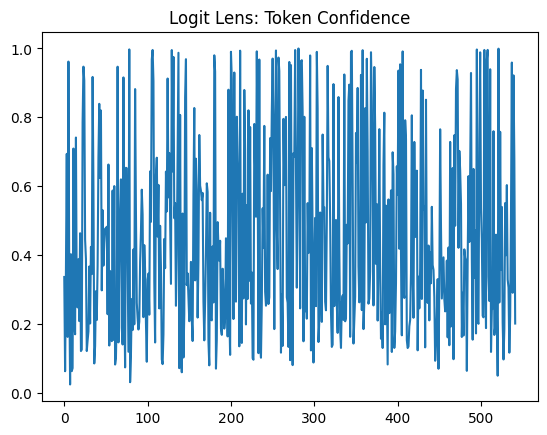

Input length before truncation: 542


<Figure size 640x480 with 0 Axes>

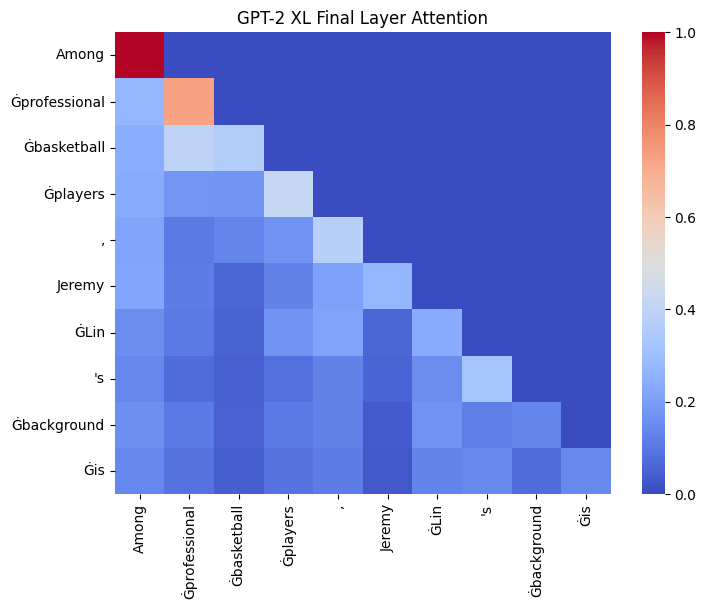

Input length before truncation: 542


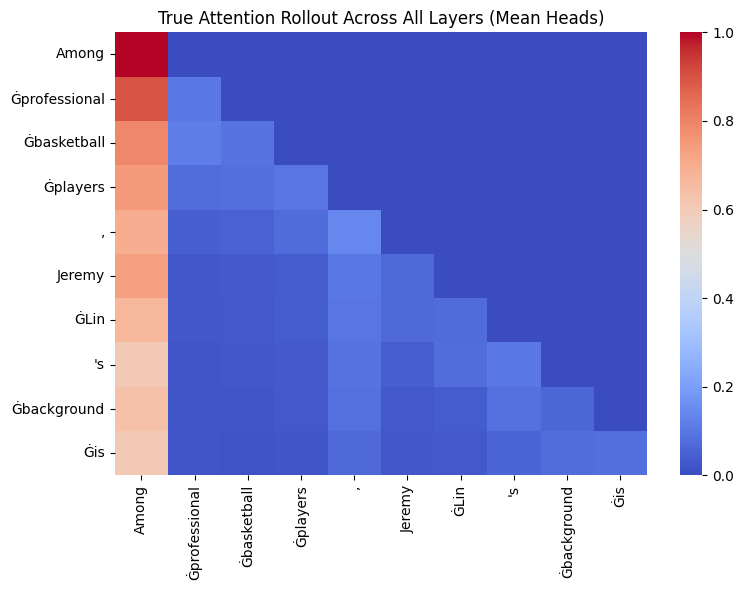

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore F1: [0.8415819]


  0%|          | 0/1 [00:00<?, ?it/s]

Prompt: Among professional basketball players,Jeremy Lin's background is not typical.He graduated from Harvard University,which sends few players to the NBA,and he is the only ChineseAmerican NBA player.But when you watch him on the court,there is no doubt that he belongs there.He moves with speed and grace  that show years of faithful practice,which is fueled by a love for basketball.
The Family Effect
Lin's enjoyment of basketball actually began in Taiwan,where his father started watching it.Lin's father moved to U.S.,and his interest in the sport only grew.He passed on this love of basketball to his son,introducing him to the game at the age of five.The young Lin spent much of his youth playing basketball for fun.After each game,his parents would discuss not only his score but also his conduct toward other players.This taught Lin that character was more important than playing well,a lesson he still remembers.
Rise of a Star
In high school,Lin dreamed of playing in the NBA but did no

100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


...

Prediction: D, Log probs: [-41.18302523903549, -33.51512253284454, -34.952194809913635, -17.18590224161744]


  0%|          | 0/1 [00:00<?, ?it/s]

Prompt: While researching a topic, a student has taken the following notes: In geology, an Aeolian landform is one that has been created by the wind. In Greek mythology, Aeolus is the keeper of the winds. Aeolian landforms are created when the wind erodes, transports, or deposits material. A mushroom rock is a rock formation in which the top is wider than the base. A mushroom rock can be formed when the wind erodes the base and the top at different rates. The student wants to provide an explanation and an example of Aeolian landforms. Which choice most effectively uses relevant information from the notes to accomplish this goal?, Options: ['Aeolian landforms are created by different wind-based processes; for example, some are created by wind erosion.', 'Aeolian landforms—landforms created by the wind—include the mushroom rock, a rock formation in which the wind erodes the base of the rock faster than the top.', 'Erosion, transportation, and deposition are three examples of how the wind

100%|██████████| 1/1 [00:00<00:00,  2.37it/s]

Prediction: C, Log probs: [-68.9208540758118, -85.90980840288103, -49.68008567788638, -68.85528197744861]
Shallow heuristic - Question: While researching a topic, a student has taken the following notes: In geology, an Aeolian landform is one that has been created by the wind. In Greek mythology, Aeolus is the keeper of the winds. Aeolian landforms are created when the wind erodes, transports, or deposits material. A mushroom rock is a rock formation in which the top is wider than the base. A mushroom rock can be formed when the wind erodes the base and the top at different rates. The student wants to provide an explanation and an example of Aeolian landforms. Which choice most effectively uses relevant information from the notes to accomplish this goal?, Matches: [1, 1, 1, 1]
Input length before truncation: 135


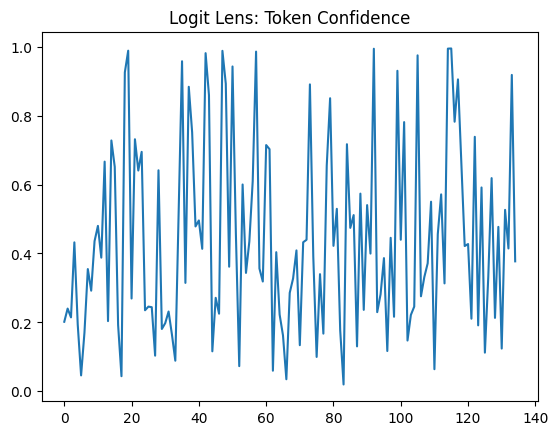

Input length before truncation: 135


<Figure size 640x480 with 0 Axes>

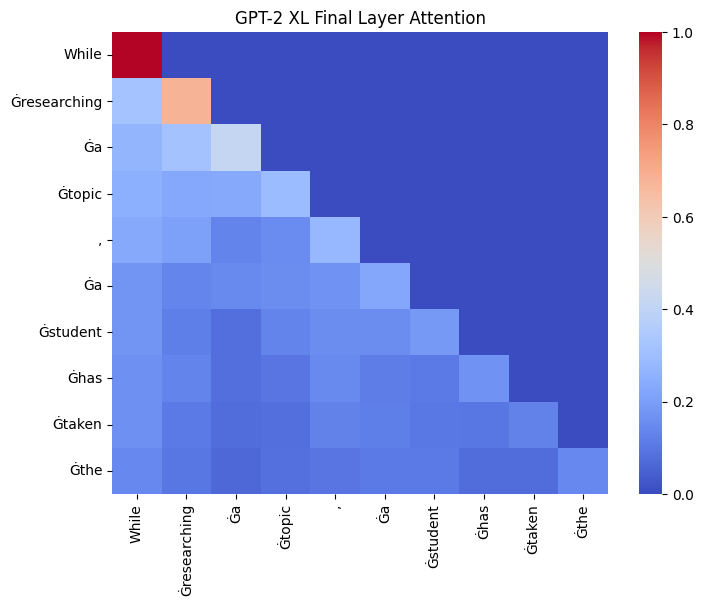

Input length before truncation: 135


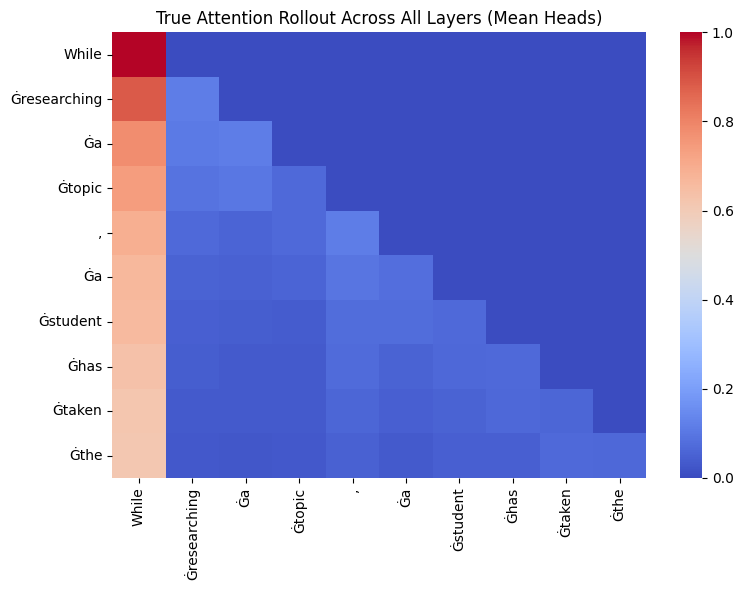

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore F1: [0.80614567]


  0%|          | 0/1 [00:00<?, ?it/s]

Prompt: While researching a topic, a student has taken the following notes: In geology, an Aeolian landform is one that has been created by the wind. In Greek mythology, Aeolus is the keeper of the winds. Aeolian landforms are created when the wind erodes, transports, or deposits material. A mushroom rock is a rock formation in which the top is wider than the base. A mushroom rock can be formed when the wind erodes the base and the top at different rates. The student wants to provide an explanation and an example of Aeolian landforms. Which choice most effectively uses relevant information from the notes to accomplish this goal?, Options: ['Aeolian landforms are created by different wind-based processes; for example, some are created by wind erosion.', 'Aeolian landforms—landforms created by the wind—include the mushroom rock, a rock formation in which the wind erodes the base of the rock faster than the top.', 'Erosion, transportation, and deposition are three examples of how the wind

100%|██████████| 1/1 [00:00<00:00,  2.35it/s]


Prediction: C, Log probs: [-68.9208540758118, -85.90980840288103, -49.68008567788638, -68.85528197744861]


  0%|          | 0/1 [00:00<?, ?it/s]

Prompt: While researching a topic, a student has taken the following notes: In geology, an Aeolian landform is one that has been created by the wind. In Greek mythology, Aeolus is the keeper of the winds. Aeolian landforms are created when the wind erodes, transports, or deposits material. A mushroom rock is a rock formation in which the top is wider than the base. A mushroom rock can be formed when the wind erodes the base and the top at different rates. The student wants to provide an explanation and an example of Aeolian landforms. Which choice most effectively uses relevant information from the notes to accomplish this goal?, Options: ['A mushroom rock is a rock formation that owes its shape to the wind, a natural force associated with Aeolus in Greek mythology.', 'Erosion, transportation, and deposition are three examples of how the wind can create Aeolian landforms and mushroom rocks.', 'Aeolian landforms—landforms created by the wind—include the mushroom rock, a rock formation i

100%|██████████| 1/1 [00:00<00:00,  2.37it/s]

Prediction: B, Log probs: [-68.85528197744861, -49.68008567788638, -85.90980840288103, -68.9208540758118]


In [ ]:
for ds in datasets:
    examples = load_data(data_dir + ds["path"])
    if len(examples) == 0:
        continue

    example = random.choice(examples)
    prompt = get_prompt(example)
    options = get_options(example)
    if not options:
        continue

    pred, logits = predict(model, [{"prompt": prompt, "options": options}])
    pred_idx = pred[0]
    option_labels = ["A", "B", "C", "D"]
    pred_label = option_labels[pred_idx]

    answer = example.get("answer") or example.get("correct")
    gold = answer.upper() if isinstance(answer, str) else answer

    # Heuristic Check
    shallow_heuristic_check(prompt, options)

    # Logit Lens
    confidences = logit_lens_visual(model, prompt)
    plt.plot(confidences)
    plt.title("Logit Lens: Token Confidence")
    plt.show()
    plt.clf()

    # Attention Maps
    attn_map, tokens = get_attention_map(model, prompt)
    plot_attention_heatmap(attn_map, tokens)

    rollout_map, rollout_tokens = true_attention_rollout(model, prompt)
    plot_attention_rollout(rollout_map, rollout_tokens)

    # BERTScore
    if gold and options:
        score = run_bertscore([gold], [options[pred_idx]])
        print("BERTScore F1:", score)

    # Contrastive Distractor Swap
    sample_example = {'prompt': prompt, 'options': options}
    original, swapped = contrastive_distractor_swap(sample_example)

  0%|          | 0/1 [00:00<?, ?it/s]

Prompt: It is the goal of politicians everywhere-----how to win and keep the trust of voters.
  Now researchers at the University of St Anurew's in Scotland say they may have the answer. They believe politicians could learn a lot from recent advances in science. A growing number of studies have shown that people do judge a book by its cover. Researchers say most of us make quick judgments about a person on the basis of how they look.
  Studies suggest that people are less likely to trust those with particularly masculine  features, such as a square jaw, small eyes or a big nose. " They are considered dominant  and less trustworthy," says Ms Cornwell. "It doesn't mean that men who look more masculine are less trustworthy-----it's just our first impression." Those with less masculine features-----larger eyes, a smaller nose and thinner lips are thought to be more trustworthy.
  The researchers are putting their science to the test at the Royal Society's annual summer exhibition in London


100%|██████████| 1/1 [00:00<00:00,  1.16it/s]


Prediction: C, Log probs: [-29.77693349123001, -39.28070305287838, -22.428976953029633, -52.885164856910706]
Shallow heuristic - Question: According to the passage, we know that   _  ., Matches: [0, 0, 1, 0]
Question: According to the passage, we know that   _  ., Options: ['people with good facial features must be trustworthy', 'people with bad facial features could not be trustworthy', 'we should judge people by their facial features', 'facial features might give people some wrong impressions'], Matches: [0, 0, 1, 0]



  0%|          | 0/1 [00:00<?, ?it/s]

...


100%|██████████| 1/1 [00:01<00:00,  1.11s/it]


Prediction: A, Log probs: [-19.84678888320923, -22.051820755004883, -26.08086395263672, -22.758270740509033]



100%|██████████| 10/10 [00:22<00:00,  2.23s/it]

Prompt: What is the main purpose of the text ?, Options: ['To inform.', 'To educate.', 'To persuade .', 'To instruct.']
Input length before truncation: 12
Input length before truncation: 12
Input length before truncation: 12
Input length before truncation: 12
Prediction: A, Log probs: [-16.383339643478394, -17.221741199493408, -21.27127742767334, -19.18522548675537]
Dataset: RACE-H
Average Reasoning Score: 0.000
Average Heuristic Dependence: 0.575
Average Context Fidelity: 0.300



use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


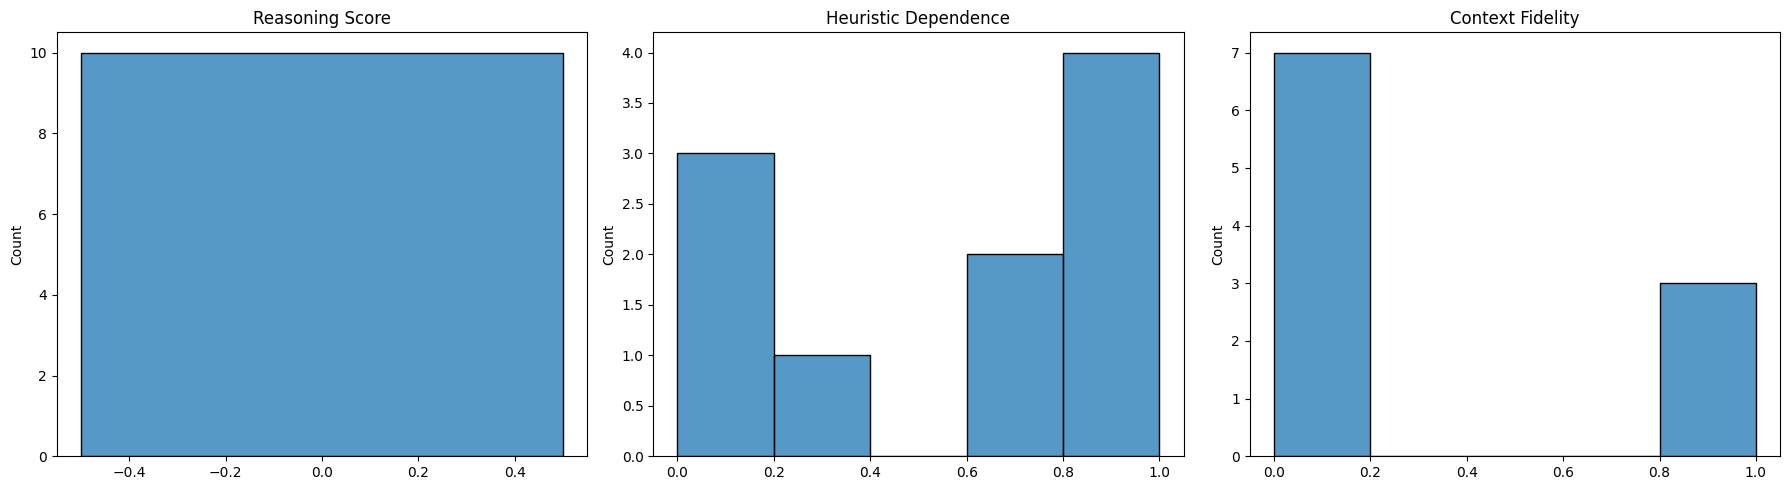

  0%|          | 0/1 [00:00<?, ?it/s]

Prompt: The following text is adapted from Paul Laurence Dunbar’s 1902 novel The Sport of the Gods. Joe and some of his family members have recently moved to New York City. [Joe] was wild with enthusiasm and with a desire to be a part of all that the metropolis meant. In the evening he saw the young fellows passing by dressed in their spruce clothes, and he wondered with a sort of envy where they could be going. Back home there had been no place much worth going to, except church and one or two people’s houses. Which choice best states the main purpose of the text?, Options: ['It illustrates a character’s reaction to a new environment.', 'It explains why a character has traveled to a city.', 'It compares a character’s thoughts about an event at two different times of day.', 'It presents a character feeling regret over leaving home.']
Input length before truncation: 139
Input length before truncation: 137
Input length before truncation: 144
Input length before truncation: 136



100%|██████████| 1/1 [00:00<00:00,  2.44it/s]


Prediction: A, Log probs: [-36.8512132781907, -42.761945605278015, -64.63959767436609, -45.84383511543274]
Shallow heuristic - Question: Which choice best states the main purpose of the text?, Matches: [1, 1, 1, 1]
Question: Which choice best states the main purpose of the text?, Options: ['It illustrates a character’s reaction to a new environment.', 'It explains why a character has traveled to a city.', 'It compares a character’s thoughts about an event at two different times of day.', 'It presents a character feeling regret over leaving home.'], Matches: [1, 1, 1, 1]



  0%|          | 0/1 [00:00<?, ?it/s]

...

Prediction: D, Log probs: [-76.49003109522164, -77.87536709755659, -71.9076512157917, -71.60042038559914]



100%|██████████| 10/10 [00:13<00:00,  1.30s/it]

Prompt: The main point of this passage is to:, Options: ["illustrate the importance of genetics in the formation of a baby's brain.", "illustrate the importance of stimulation and experience in the formation of a baby's brain.", "indicate the great need for conducting further research on babies' brains.", "compare the latest research on babies' brains with similar research conducted fifteen years ago."]
Input length before truncation: 23
Input length before truncation: 25
Input length before truncation: 22
Input length before truncation: 25
Prediction: C, Log probs: [-86.0233029127121, -95.52514197677374, -80.58815550804138, -81.45572786033154]
Dataset: SATACT
Average Reasoning Score: 0.000
Average Heuristic Dependence: 0.700
Average Context Fidelity: 0.400



use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


<Figure size 640x480 with 0 Axes>

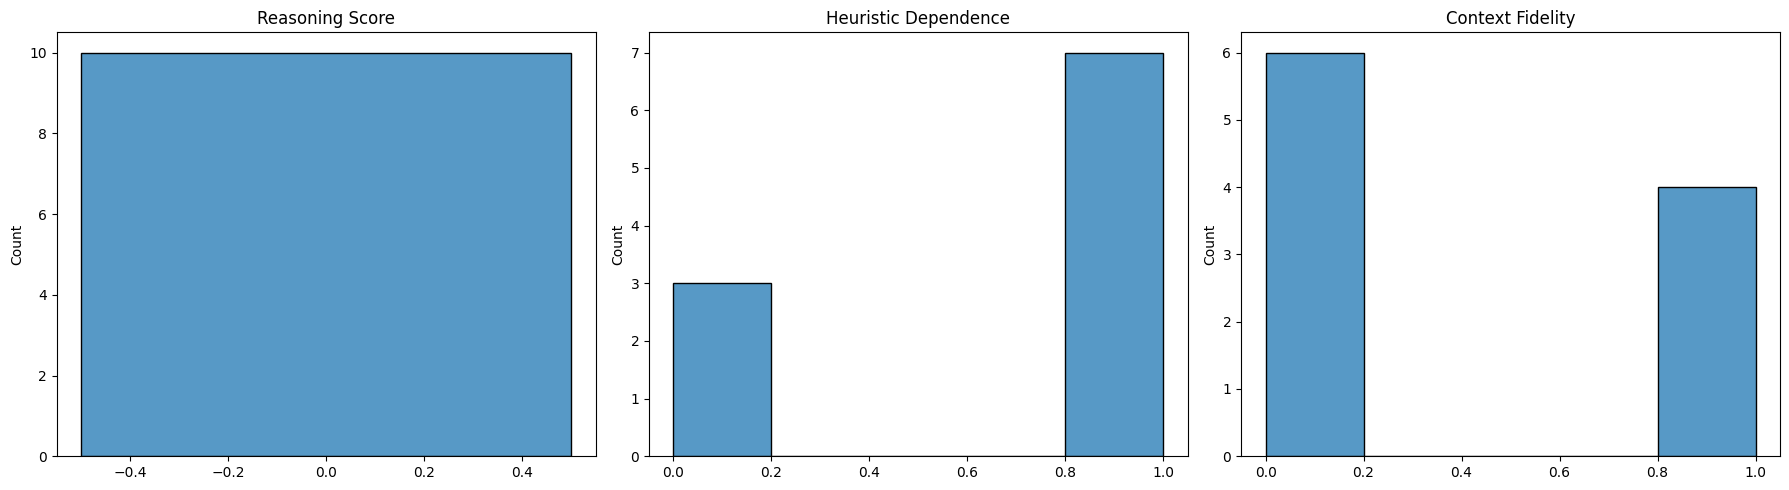

<Figure size 640x480 with 0 Axes>

In [ ]:
for ds in datasets:
    interpretability_report(model, ds)

In [ ]:
"""batch_size = 25

for ds in datasets:
    dataset_path = data_dir + ds["path"]
    total = len(load_data(dataset_path))

    for offset in range(0, total, batch_size):
        output_csv = os.path.join(save_dir, f"{ds['name']}_offset{offset}.csv")
        compute_scores_and_export(ds, output_csv, limit=batch_size, offset=offset)
"""

'batch_size = 25\n\nfor ds in datasets:\n    dataset_path = data_dir + ds["path"]\n    total = len(load_data(dataset_path))\n\n    for offset in range(0, total, batch_size):\n        output_csv = os.path.join(save_dir, f"{ds[\'name\']}_offset{offset}.csv")\n        compute_scores_and_export(ds, output_csv, limit=batch_size, offset=offset)\n'

In [ ]:
import glob

batch_size = 25

for ds in datasets:
    dataset_path = data_dir + ds["path"]
    total = len(load_data(dataset_path))

    existing_offsets = set()
    existing_files = glob.glob(os.path.join(save_dir, f"{ds['name']}_offset*.csv"))
    for f in existing_files:
        try:
            offset_part = os.path.basename(f).split("_offset")[1].split(".")[0]
            existing_offsets.add(int(offset_part))
        except:
            continue

    print(f"\nResuming {ds['name']} — skipping offsets: {sorted(existing_offsets)}")

    for offset in range(0, total, batch_size):
        if offset in existing_offsets:
            continue
        output_csv = os.path.join(save_dir, f"{ds['name']}_offset{offset}.csv")
        compute_scores_and_export(ds, output_csv, limit=batch_size, offset=offset)


Resuming RACE-H — skipping offsets: [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375, 400, 425, 450, 475, 500, 525, 550, 575, 600, 625, 650, 675, 700, 725, 750, 775, 800, 825, 850, 875, 900, 925, 950, 975, 1000, 1025, 1050, 1075, 1100, 1125, 1150, 1175, 1200, 1225, 1250, 1275, 1300, 1325, 1350, 1375, 1400, 1425, 1450, 1475, 1500, 1525, 1550, 1575, 1600, 1625, 1650, 1675, 1700, 1725, 1750, 1775, 1800, 1825, 1850, 1875, 1900, 1925, 1950, 1975, 2000, 2025, 2050, 2075, 2100, 2125, 2150, 2175, 2200, 2225, 2250, 2275, 2300, 2325, 2350, 2375, 2400, 2425, 2450, 2475, 2500, 2525, 2550, 2575, 2600, 2625, 2650, 2675, 2700, 2725, 2750, 2775, 2800, 2825, 2850, 2875, 2900, 2925, 2950, 2975, 3000, 3025, 3050, 3075, 3100, 3125, 3150, 3175, 3200, 3225, 3250, 3275, 3300, 3325, 3350, 3375, 3400, 3425, 3450, 3475]

Resuming SATACT — skipping offsets: [0, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250]


In [ ]:
for ds in datasets:
    all_files = glob.glob(os.path.join(save_dir, f"{ds['name']}_offset*.csv"))
    merged_df = pd.concat([pd.read_csv(f) for f in all_files])
    merged_df.to_csv(os.path.join(save_dir, f"{ds['name']}_interpretability_merged.csv"), index=False)